<a href="https://colab.research.google.com/github/ColdBottle0226/RAG_PRAC/blob/main/%5B3%E1%84%80%E1%85%A1%E1%86%BC%5D_Agent_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -qU langchain "langchain[openai]"

In [ ]:
import os

os.environ["OPENAI_API_KEY"] = "sk-proj-"

### Tool 기초

In [ ]:
# Tool
# 모델(LLM)이 외부 시스템(API, DB, 파일 시스템 등)과 상호작용하기 위해 사용하는 요소
# 구성 요소 : 1) 호출 가능한 함수 + 2) 입력 스키마
# 학습 시점 이전의 데이터를 바탕으로 학습했기 때문에, LLM만으로는 답변이 어렵다 -> Tool 활용

# Tool 작성법
# 1. 함수 작성
# 2. 타입 힌팅
# 3. docstring으로 함수(Tool) 설명
# 3. @tool 데코레이터 입력

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

In [ ]:
response = model.invoke("현재 한국 날씨 어때?")

In [ ]:
print(response)

content='현재 한국의 실시간 날씨를 바로 알려드리려면 최신 데이터를 조회해야 하는데, 이 대화에서는 실시간 조회 기능이 항상 자동으로 연결돼 있지 않을 수 있어요. 원하시는 도시를 알려주시면 그 도시의 현재 날씨를 알려드리거나, 인터넷에서 최신 정보를 확인하는 방법도 안내해 드릴게요.\n\n다음 중 어떤 걸 원하시나요?\n- 특정 도시의 현재 날씨 확인하고 싶어요(예: 서울, 부산, 제주 등)\n- 한국의 일반적인 계절별 날씨 경향이나 3월의 특징을 알고 싶어요\n- 바로 실시간 정보를 직접 확인하는 방법 안내를 원해요 (날씨 앱/웹사이트 사용법)' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 1380, 'prompt_tokens': 13, 'total_tokens': 1393, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1216, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJbKkzjoaXjfBB8ULXGWskbgV3t9d', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019cf0a8-b2c1-7823-bbf7-056e7fd2376c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 13

In [ ]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
  """특정 지역의 날씨 정보 제공하는 도구"""
  return f"{location}의 날씨는 맑고, 영하 2도입니다."

In [ ]:
# Tool - Model 연동(Agent 객체 생성)
from langchain.agents import create_agent
agent = create_agent(model, tools=[get_weather])

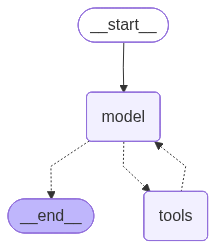

In [ ]:
agent

In [ ]:
# invoke() 메서드로 Agent 실행
# messages에 담긴 리스트 속 마지막 content(result["messages"][-1].content) 에 최종 응답 확인

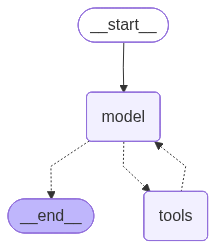

In [ ]:
from IPython.display import Image, display

# 그래프 구조 확인
display(Image(agent.get_graph().draw_mermaid_png()))

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨 어때요?"}]}, # Human message로 질문 저장
)

# ToolMessage로 메서드의 content가 반환되고,
# 이후에 AIMessage에 결과 내용이 반영되어 반환된다.
result

#print(result["messages"][-1].content)

{'messages': [HumanMessage(content='서울 날씨 어때요?', additional_kwargs={}, response_metadata={}, id='ed3bffb6-af13-4fbb-8959-d63077eb1d7b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 215, 'prompt_tokens': 136, 'total_tokens': 351, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJbWkhbjOdPC5WHwGcm6uxlUXeGko', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf0b4-0f96-70f3-9090-0f3c0a6b649d-0', tool_calls=[{'name': 'get_weather', 'args': {'location': '서울'}, 'id': 'call_JsrosRmnRlbJ3SwU3nxyB2bu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 136, 'output_tokens': 215, 'total_to

In [ ]:
# Model이 content를 생성하지 않고, tool_calls로 get_weather 도구 호출
# 도구는 응답을 ToolMessage에 담아 응답
# Model은 도구의 응답을 참조해 답변 생성

# Tool을 호출할지 말지, 어떤 Tool을 호출할지, 추론 및 행동하는 것은 Model이 수행한다.

## Tool 응용 1

In [ ]:
# 기본적인 Tool 응용 흐름
# Human Message -> AI Message -> Tool Message -> AI Message

# 시스템 메시지 부여
# System Message -> Human Message -> AI Message -> Tool Message -> AI Message

In [ ]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """`a`와 `b` 덧셈.

    Args:
        a: First int
        b: Second int
    """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """`a`와 `b` 곱셈.

    Args:
        a: First int
        b: Second int
    """
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """`a`와 `b` 나눗셈.

    Args:
        a: First int
        b: Second int
    """
    return a / b

In [ ]:
tools = [add, multiply, divide]

In [ ]:
agent = create_agent(model, tools)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "42 + 3 * 23은 뭔가요?"}]},
)

In [ ]:
result # AI 메시지가 Tool을 사용하지 않고, 바로 만들어짐 (확률기반이기 때문에, 도구를 사용하지 않아도 답변가능하면 바로 답변할 수 있다.) => System Message 사용

{'messages': [HumanMessage(content='42 + 3 * 23은 뭔가요?', additional_kwargs={}, response_metadata={}, id='ea7b1c48-8e74-478d-b21e-a9ca3e554cf7'),
  AIMessage(content='111입니다. 먼저 3 × 23 = 69이고, 그다음 42 + 69 = 111이니까요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 358, 'prompt_tokens': 244, 'total_tokens': 602, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJbehlsHiNEKgJW11Ql8QXCs47Cjd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf0bb-9334-7e81-9598-5b56bb1582ce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 244, 'output_tokens': 358, 'total_tokens': 602, 'input_token_details': {'audio': 0, 'cache_read': 

In [ ]:
agent = create_agent(
    model,
    tools,
    system_prompt="당신은 유능한 수학 선생님입니다. 사칙 연산 요청 시 모든 단계에서 Tool을 이용하시오."
)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "42 + 3 * 23은 뭔가요?"}]},
)

In [ ]:
result

{'messages': [HumanMessage(content='42 + 3 * 23은 뭔가요?', additional_kwargs={}, response_metadata={}, id='2d5df1c3-bf60-4625-ae00-466bf605a6c8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 474, 'prompt_tokens': 275, 'total_tokens': 749, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJbiC8IY8GHyj72m2qLBgPmTHoYuW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf0be-e2df-77e2-b860-757c067187ce-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_tINy2vmt1N9oCQAmwUEZBKvP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 275, 'output_tokens': 474, 'total

In [ ]:
{'messages': [
    HumanMessage(content='42 + 3 * 23은 뭔가요?', additional_kwargs={}, response_metadata={}, id='d668f973-433b-43a6-832c-12f69d7a1d47'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 666, 'prompt_tokens': 271, 'total_tokens': 937, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0BtgC1vSXVOqkym1wLgdCHV0mg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--e3ff5826-b8ae-45ef-b321-845634280cac-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_6JIP9XWGEL4Y8gsDf7kLMCns', 'type': 'tool_call'}], usage_metadata={'input_tokens': 271, 'output_tokens': 666, 'total_tokens': 937, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 640}}),
    ToolMessage(content='69', name='multiply', id='ce3260fd-d978-4f22-9ac8-7ecba8497b5c', tool_call_id='call_6JIP9XWGEL4Y8gsDf7kLMCns'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 302, 'total_tokens': 322, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0IzrIXR33PjGJkChQkJNBWEPNp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--79f83b57-4a2b-4ceb-8dd1-79bb8ac2907c-0', tool_calls=[{'name': 'add', 'args': {'a': 42, 'b': 69}, 'id': 'call_dYzyonAijap4wIkosXukpffe', 'type': 'tool_call'}], usage_metadata={'input_tokens': 302, 'output_tokens': 20, 'total_tokens': 322, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
    ToolMessage(content='111', name='add', id='a30c98b9-41e5-4496-aed3-044c02028346', tool_call_id='call_dYzyonAijap4wIkosXukpffe'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 666, 'prompt_tokens': 333, 'total_tokens': 999, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0KeTPVjeebFxGf8IXHbmsLUKQ9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--3e09231b-dfd0-4190-9c22-024988cc4389-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_7i9W8KYCfoyL0V5YM3hA9CNM', 'type': 'tool_call'}], usage_metadata={'input_tokens': 333, 'output_tokens': 666, 'total_tokens': 999, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 640}}),
    ToolMessage(content='69', name='multiply', id='f041ffd3-626e-4541-9ea7-db7c200a49ef', tool_call_id='call_7i9W8KYCfoyL0V5YM3hA9CNM'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 922, 'prompt_tokens': 364, 'total_tokens': 1286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 896, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0QZAwvbco2nLwS2UlXoKoQJ2zB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--eb606c0c-8c16-4789-928d-2ed8e902074f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_bUU09sNKZb2CMKxPwn3dc7pW', 'type': 'tool_call'}], usage_metadata={'input_tokens': 364, 'output_tokens': 922, 'total_tokens': 1286, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 896}}),
    ToolMessage(content='69', name='multiply', id='9ae49215-1418-4f1b-88e3-c32caa9dd511', tool_call_id='call_bUU09sNKZb2CMKxPwn3dc7pW'),
    AIMessage(content='정답은 111입니다.\n\n설명:\n- 먼저 곱셈의 순서를 따릅니다: 3 * 23 = 69\n- 그리고 남은 더하기를 수행합니다: 42 + 69 = 111\n\n추가로, 계산 과정을 한 번에 확인하는 방법도 보여드리면:\n- 42 + 3 * 23 = 42 + (3 * 23) = 42 + 69 = 111\n\n필요한 다른 연산이 있으면 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 395, 'total_tokens': 510, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0Ywh5LSATE3IezdrYTcoik9Abu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--79aa9996-99f3-4463-9986-b33c4f53d706-0', usage_metadata={'input_tokens': 395, 'output_tokens': 115, 'total_tokens': 510, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
    ]
}

In [ ]:
result["messages"][-1].content

'정답은 111입니다.\n\n계산 과정:\n- 3 × 23 = 69\n- 42 + 69 = 111'

## Tool 응용 2 - 알라딘 API

In [ ]:
response = model.invoke("현재 알라딘에서 베스트셀러 Top10 뭐야?")

In [ ]:
response

AIMessage(content='지금 바로 실시간 정보를 확인해 드리려면 웹 검색이 필요해요. 제 환경에서 바로 알라딘 사이트의 현재 Top 10을 자동으로 불러오진 못합니다.\n\n대신 직접 확인하는 방법 간단히 안내드릴게요:\n- 알라딘 홈페이지 접속: aladin.co.kr\n- 상단 메뉴에서 “베스트셀러” 클릭\n- 원하는 범주를 선택(종합 베스트셀러를 기본으로 가장 많이 보는 Top 10이 표시됩니다)\n- 상단 10개 항목이 Top 10 목록으로 보여요\n\n원하시면 제가 도와드리는 alternative도 있어요:\n- 지금 이 페이지의 Top 10 링크를 보내주시면 제가 목록을 읽어 정리해 드립니다.\n- 또는 특정 분야(소설, 에세이, 자기계발 등)나 날짜 범위를 말씀해 주시면 그 범주로 Top 10를 추려 드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1686, 'prompt_tokens': 21, 'total_tokens': 1707, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1472, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJbls1PCLJaQKGc2ZzUhXTnTFx4Jb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf

In [ ]:
#print(result["messages"][-1].content)

In [ ]:
from langchain.tools import tool
from typing import List, Dict, Any

import requests

@tool
def fetch_aladin_bestseller_top10() -> List[Dict[str, Any]]:
    """
    알라딘 베스트셀러 목록을 조회하고 Top N개(기본 10)를 반환합니다.
    """
    url = "http://www.aladin.co.kr/ttb/api/ItemList.aspx"
    params = {
        "ttbkey": "ttb",
        "QueryType": "Bestseller",
        "MaxResults": 10,
        "start": 1,
        "SearchTarget": "Book",
        "output": "js",
        "Version": "20131101"
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    data = resp.json()
    items = data.get("item", [])
    top10 = items[:10]
    return top10

In [ ]:
agent = create_agent(model, tools=[fetch_aladin_bestseller_top10])

In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "현재 알라딘에서 베스트셀러 Top10 뭐야?"}]},
)

In [ ]:
response

{'messages': [HumanMessage(content='현재 알라딘에서 베스트셀러 Top10 뭐야?', additional_kwargs={}, response_metadata={}, id='77bb671f-c9c0-464d-bb80-cfe28d89dbfd'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 217, 'prompt_tokens': 157, 'total_tokens': 374, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJbsugnrQLqYZsBWEAl8tOMZXccFD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf0c9-05aa-7772-bff8-792e90f2e46f-0', tool_calls=[{'name': 'fetch_aladin_bestseller_top10', 'args': {}, 'id': 'call_umy8ITNZmEZHVGT7S9Ss7Yya', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 157, 'output_tokens'

In [ ]:
response["messages"][-1].content

'다음이 현재 알라딘 베스트셀러 Top 10입니다.\n\n1) 괴테는 모든 것을 말했다 - 제172회 아쿠타가와상 수상작 — 스즈키 유이(지은이), 이지수(옮긴이)  \n2) 인생을 위한 최소한의 생각 — 신영준, 고영성(지은이)  \n3) 프로젝트 헤일메리 (영화 특별판) — 앤디 위어(지은이), 강동혁(옮긴이)  \n4) 스파이 패밀리 16 — 엔도 타츠야(지은이)  \n5) 완벽한 원시인 - 10만 년을 되돌려 되찾는 뇌 설계도 — 자청(지은이)  \n6) 햄릿 (먼슬리 클래식) — 윌리엄 셰익스피어(지은이), 이경식(옮긴이)  \n7) 기븐 10th mix - 뉴 루비코믹스 3150 — 키즈 나츠키(지은이)  \n8) 죽은 왕녀를 위한 파반느 (양장 특별판) — 박민규(지은이)  \n9) 슈퍼 뒤에서 담배 피우는 두 사람 7 (특별판) — 지누시(지은이), 김성래(옮긴이)  \n10) 인생 마지막에 쓰는 주식투자 교과서 — 정규준(지은이)\n\n원하시면 각 작품의 간단한 줄거리나 링크도 같이 드릴게요.'

## Memory

In [ ]:
# 다중 턴 대화 시 대화 맥락을 고려한 Tool 호출을 위해 메모리 관리 필요
# 메모리 종류
# 1) Short-term memory : Checkpointer를 통해 대화 스레드(세션) 저장 (현재 대화 창)
# 2) Long-term memory : Store 를 통해 장기 메모리 저장

### Short-term memory (Checkpointer)
- Checkpointer : 스레드(대화 상태)를 저장할 저장소
- checkpointer=InMemorySaver() -> 기억용 수첩과 펜을 Agent에게 쥐여주기

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model,
    tools,
    checkpointer=InMemorySaver()
)

In [ ]:
# 대화 저장 1. thread_id 1에 첫 번째 대화 저장
response = agent.invoke(
    {"messages":[{"role": "user", "content": "안녕하세요! 저는 Chan입니다."}]},
    {"configurable": {"thread_id": "1"}}
)

In [ ]:
response

{'messages': [HumanMessage(content='안녕하세요! 저는 Chan입니다.', additional_kwargs={}, response_metadata={}, id='2c1110e1-7e2b-4172-9258-a6a3cf082b47'),
  AIMessage(content='반갑습니다, Chan님! 어떻게 도와드릴까요? 수학 문제 풀이, 간단한 계산(덧셈/뺄셈/곱셈/나눗셈), 정보 탐색 등 어떤 도움이 필요하신지 말씀해 주세요. 필요하신 만큼 바로 도와드리겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 337, 'prompt_tokens': 238, 'total_tokens': 575, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJc82uwAdqUKsGDE3C8bJl5HMOu1h', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf0d7-53bd-7af3-b735-9b21c469aacf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 238, 'output_tokens': 337, 'total_tok

In [ ]:
print(response["messages"][-1].content)

반갑습니다, Chan님! 어떻게 도와드릴까요? 수학 문제 풀이, 간단한 계산(덧셈/뺄셈/곱셈/나눗셈), 정보 탐색 등 어떤 도움이 필요하신지 말씀해 주세요. 필요하신 만큼 바로 도와드리겠습니다.


In [ ]:
# 같은 스레드 ID 주어야 한다
response = agent.invoke(
    {"messages":[{"role": "user", "content": "제 이름이 뭐라고 했죠?"}]},
    {"configurable": {"thread_id": "1"}}
 )

NameError: name 'agent' is not defined

In [ ]:
print(response["messages"][-1].content)

Chan이라고 하셨습니다. 앞으로 이 대화에서도 Chan님으로 불러드리겠습니다. 지금 도와드릴 일이 있을까요?


In [ ]:
response = agent.invoke(
    {"messages":[{"role": "user", "content": "제 이름이 뭐라고 했죠?"}]},
    {"configurable": {"thread_id": "2"}}
)

In [ ]:
print(response["messages"][-1].content)

지금 이 대화에서 당신의 이름을 아직 모릅니다. 이름을 알려주시면 이 대화에서 기억해둘게요. 어떤 이름으로 불러드릴까요? 아니면 “사용자님”으로 불러도 될까요?


In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "지금까지 무슨 얘기 나눴죠?"}]},
    {"configurable": {"thread_id": "1"}},
)

In [ ]:
response["messages"][-1].content

'지금까지의 대화 요약:\n- Chan님이 본인 이름으로 Chan이라고 소개하셨습니다.\n- 제가 반갑게 인사드리며 어떤 도움을 드릴지 여쭈었습니다(수학 문제 풀이, 간단한 계산, 정보 탐색 등).\n- Chan님이 제 이름을 물으셔서 Chan이라고 답했고, 앞으로도 Chan님이라고 부르겠습니다라고 확인했습니다.\n\n이제 어떤 도움을 드릴까요? 예를 들어 수학 문제 풀이, 간단한 계산, 자료 찾기 등 원하는 부탁을 말씀해 주세요.'

In [ ]:
for i, msg in enumerate(response["messages"]):
    print(f"--- Message {i+1} ---")
    print(msg.content)
    print()

--- Message 1 ---
안녕하세요! 저는 Chan입니다.

--- Message 2 ---
반갑습니다, Chan님! 어떻게 도와드릴까요? 수학 문제 풀이, 간단한 계산(덧셈/뺄셈/곱셈/나눗셈), 정보 탐색 등 어떤 도움이 필요하신지 말씀해 주세요. 필요하신 만큼 바로 도와드리겠습니다.

--- Message 3 ---
제 이름이 뭐라고 했죠?

--- Message 4 ---
Chan이라고 하셨습니다. 앞으로 이 대화에서도 Chan님으로 불러드리겠습니다. 지금 도와드릴 일이 있을까요?

--- Message 5 ---
지금까지 무슨 얘기 나눴죠?

--- Message 6 ---
지금까지의 대화 요약:
- Chan님이 본인 이름으로 Chan이라고 소개하셨습니다.
- 제가 반갑게 인사드리며 어떤 도움을 드릴지 여쭈었습니다(수학 문제 풀이, 간단한 계산, 정보 탐색 등).
- Chan님이 제 이름을 물으셔서 Chan이라고 답했고, 앞으로도 Chan님이라고 부르겠습니다라고 확인했습니다.

이제 어떤 도움을 드릴까요? 예를 들어 수학 문제 풀이, 간단한 계산, 자료 찾기 등 원하는 부탁을 말씀해 주세요.



In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "지금까지 무슨 얘기 나눴죠?"}]},
    {"configurable": {"thread_id": "2"}},
)

In [ ]:
for i, msg in enumerate(response["messages"]):
    print(f"--- Message {i+1} ---")
    print(msg.content)
    print()

## Middleware

MiddleWare : Agent 내부에서 일어나는 일을 섬세하게 컨트롤하는 방법
기능
- Agent 내부 활동 모니터링 및 컨트롤
- 프롬프트, tool 선택, 출력 포맷 수정
- 가드레일(개인정보 인식, 프롬프트 인젝션 방지)

### Built-in middleware

- 랭체인 빌트 인 미들웨어 종류
  - Summarization (대화 요약)
  - Human-in-the-loop(사용자 개입)
  - Model call limit (모델 호출제한)
  - Tool call limit (도구 호출 제한)
  - Model fallback (대체 모델)
  - PII detection(개인정보 탐지)
  - Todo list (할 일 목록)
  - LLM toll selector(LLM 기반 도구 선택)
  - Tool retry(도구 재시도)
  - LLM tool emulator(LLM기반 tool 흉내내기)
  - Context editing (컨텍스트 편집)

#### LLM tool emulator (LLM 기반 도구 선택)

In [ ]:
from langchain.tools import tool
from typing import List, Dict


# 이메일 전송 도구 (내부 로직은 작성되지 않음)
@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """
    지정한 이메일 주소로 메일을 보내는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 전송되었습니다.\n수신자: {to}\n제목: {subject}\n내용: {body[:50]}..."


# 이메일 읽기 도구 (내부 로직은 작성되지 않음)
@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    최근 받은 이메일 3개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."

In [ ]:
from langchain.agents.middleware import LLMToolEmulator

agent = create_agent(
    model="gpt-5-nano",
    tools=[send_email_tool, read_email_tool],
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
    ],
)

In [ ]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "최근 온 메일 확인하고 알아서 답장해줘."} # 예시 샘플로 툴과 답변을 생성한다.
        ]
    }
)

In [ ]:
response

{'messages': [HumanMessage(content='최근 온 메일 확인하고 알아서 답장해줘.', additional_kwargs={}, response_metadata={}, id='f8f5fd1e-73b3-40fd-8cbd-9aa876cc2103'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 729, 'prompt_tokens': 189, 'total_tokens': 918, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJeorSQAkdBGnLchq3vNjOQVvg8oW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf175-246a-7f10-8f8b-d7aa25a55afe-0', tool_calls=[{'name': 'read_email_tool', 'args': {'limit': 3}, 'id': 'call_euMisVCfhosFnHccGcEjrrGf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 189, 'output_tokens': 729,

In [ ]:
print(response["messages"][-1].content)

아래와 같이 최근 3통 이메일에 대해 자동으로 답장을 보내드렸습니다.

요약
- 보낸 사람: 이혜민 <hye.min@example.com>
  - 제목: Re: 팀 업데이트 회의록 공유드립니다
  - 상태: 발송 완료
  - 메시지 ID: <20260315-092430@example.com>
  - 전송 시간: 2026-03-15 09:24:30 UTC
  - 핵심 내용: 회의 요약본 확인 감사 및 첨부 파일 확인 언급, 필요 시 후속 조치 및 일정 조정 제안

- 보낸 사람: 주식시장 뉴스레터 <newsletter@marketwatch.co>
  - 제목: Re: 오늘의 주목 종목과 시장 요약
  - 상태: 발송 완료
  - 메시지 ID: email_20260315_114210
  - 전송 시간: 2026-03-15 11:42:10 UTC
  - 핵심 내용: 요약 감사합니다 인사, 특정 종목이나 분석 링크 요청 시 반영 의사 표현

- 보낸 사람: 주문 처리 <orders@example.com>
  - 제목: Re: 주문 #28472 배송 지연 안내
  - 상태: 발송 완료
  - 메시지 ID: <MSG-20260315-174512@example.com>
  - 전송 시간: 2026-03-15 17:45:12 UTC
  - 핵심 내용: 배송 정보 및 추적 번호 공유 요청, ETA 확정 시 즉시 안내 부탁드림, 불편에 대한 사과

다음에 원하시는 것
- 더 다듬은 톤으로 수정하거나 특정 포인트를 강조해 드릴까요? 예: 더 친절하게, 더 간결하게, 또는 공식적으로.
- 각 메일에 대한 자동 후속 조치를 추가로 설정해 드릴까요? 예: 일정 공유 요청, 첨부 파일 확인 여부 확인 메일 발송 등.
- 받은 답장을 자동으로 요약해 드리거나, 중요한 메일에 대해 알림 받도록 설정할까요?
- 원하시면 앞으로 24시간 이내의 수신 메일에 대해 동일한 방식으로 자동 답장을 시도하는 규칙도 만들 수 있습니다.

필요하신 방향을 알려주시면 바로 반영하겠습니다.


In [ ]:
print(response)

#### 2. Todo list

In [ ]:
from langchain.tools import tool
from typing import List, Dict


# 이메일 전송 도구
@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """
    지정한 이메일 주소로 메일을 보내는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 전송되었습니다.\n수신자: {to}\n제목: {subject}\n내용: {body[:50]}..."


# 이메일 읽기 도구
@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    최근 받은 이메일 3개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."

In [ ]:
from langchain.agents.middleware import LLMToolEmulator, TodoListMiddleware


agent = create_agent(
    model="gpt-5-nano",
    tools=[send_email_tool, read_email_tool],
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
        TodoListMiddleware()
    ],
)

In [ ]:
result = agent.invoke({
    "messages": [
            {"role": "user", "content": "온 메일 다 확인한 뒤 나한테 요약해 보고해. 그 다음 답장 작성해 회신 보내줘. 마지막으로 어떻게 보냈는지 보고하고."}
    ]
})

In [ ]:
result

{'messages': [HumanMessage(content='온 메일 다 확인한 뒤 나한테 요약해 보고해. 그 다음 답장 작성해 회신 보내줘. 마지막으로 어떻게 보냈는지 보고하고.', additional_kwargs={}, response_metadata={}, id='49f61ac7-60cf-4114-91e2-3d07e93422dd'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1432, 'prompt_tokens': 1285, 'total_tokens': 2717, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1408, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJevKlANTloJS2NZzWIC9fKAXkvt0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf17b-42e0-7341-a7d3-f54b0920630a-0', tool_calls=[{'name': 'read_email_tool', 'args': {'limit': 3}, 'id': 'call_RXhzfhKVF5Ouq0JVwiTek26g', 'type': 'tool_call'}], invalid_tool_calls=[], usage_meta

In [ ]:
print(result["messages"][-1].content)

다 읽고 요약 및 회신 내역 정리드립니다.

1) 온 메일 요약
- Maria Chen <maria.chen@acme.co> (2026-03-15 09:32)
  - 제목: Q2 budget review – draft attached
  - 내용 핵심: 2분기 예산 초안 첨부. headcount(인원) 증가율 4%, 마케팅 지출 10% 증가, 매출 전망 수정. leadership 회의 전까지 피드백 수집 필요.
- Sarah Patel <sarah.patel@acme.co> (2026-03-15 08:10)
  - 제목: Campaign proposal for Product X
  - 내용 핵심: Product X용 초안 캠페인 제안서 업로드. 채널(디지털, 이벤트), 8주 일정, 성공 지표(CPA, CTR, ROAS) 포함. 예산 조정 여부 및 추가 채널 반영 여부 제안 요청.
- GitHub Notifications <noreply@github.com> (2026-03-14 21:01)
  - 제목: New pull request in your repository: product-x
  - 내용 핵심: product-x 저장소에 새로운 PR 생성. 프론트엔드 컴포넌트 변경 및 README 업데이트. 검토 및 피드백/승인 요청.

2) 보낸 답장 내용 및 발송 상황
- 보낸 첫 번째 답장
  - 받는 사람: Maria Chen
  - 제목: Re: Q2 budget review – draft attached
  - 본문 요지:
    - "Thanks for sharing the preliminary Q2 budget forecast. I will review the headcount figures and the marketing spend and plan to consolidate feedback ahead of the leadership meeting. If you could confirm whether the 4% headcount increase in

In [ ]:
print(result)

#### 3. Human-in-the-loop : 작업 전 사용자의 의사를 묻는 미들웨어
- 반드시 checkpointer와 함께 사용(메모리)
- allow_descisions 옵션 (approve, edit, reject)

In [ ]:
from langchain.tools import tool

@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    최근 받은 이메일 3개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."


@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """이메일을 발송하는 도구"""
    return f"{to}에게 메일을 보냈습니다.\n제목: {subject}\n내용: {body[:40]}..."

In [ ]:
from langchain.agents.middleware import LLMToolEmulator, HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


agent = create_agent(
    model,
    tools=[send_email_tool, read_email_tool],
    # 체크포인터 연결 (반드시 함께 사용)
    checkpointer = checkpointer,
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
        HumanInTheLoopMiddleware(
            interrupt_on={
                # 이메일 발송 툴 사용시,
                "send_email_tool": {
                    # 사람이 개입할 권한
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False # 개입 없음
            }
        )
    ],
)

In [ ]:
prompt = "무슨 메일 왔는지 확인해줘"

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
    {"configurable": {"thread_id": "HIL-a"}}
)

In [ ]:
print(response["messages"][-1])

content='다음 3통의 메일이 도착했습니다.\n\n1) 보낸 사람: Ava Park <ava.park@example.org>\n   날짜: 2026-03-15 08:45\n   제목: Project Aurora - kickoff notes\n   내용 요약:\n   - 주요 아이템: MVP 5월 30일, Beta 6월 20일\n   - 담당자: Ava (PM), Jin (Tech Lead)\n   - 리스크 로그: API v2 의 의존성, 벤더 지연으로 일정 지연 가능\n   - 요청: 수정사항이 있으면 회신 부탁\n\n2) 보낸 사람: Billing <billing@contoso.co>\n   날짜: 2026-03-14 17:03\n   제목: Invoice #INV202603-8742 due soon\n   내용 요약:\n   - 청구서: 2026년 3월분\n   - 총액: $1,250.00\n   - 납부 기한: 2026-04-15\n   - 결제 방법: 링크 참조\n   - 문의: 문의 시 회신\n\n3) 보낸 사람: Scheduler Bot <no-reply@scheduler.example.com>\n   날짜: 2026-03-13 12:15\n   제목: Team meeting moved to 3:00 PM today\n   내용 요약:\n   - 오늘 미팅 시간이 3:00 PM으로 변경, 장소: Conference Room B\n   - 의제: 프로젝트 업데이트, blockers, 다음 단계\n   - 달력 조정 부탁, 참석 불가 시 알려달라\n\n원하시면:\n- 특정 메일의 상세 내용을 더 확인해 드리거나\n- 회신 초안 작성해 드리거나\n- 회신/일정 변경/결제 확인 같은 간단한 액션도 도와드릴게요.\n\n어떤 메일부터 다루면 될까요?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 1311, 'prompt_tokens':

In [ ]:
prompt = "교수님한테 내일 찾아뵙겠다는 메일 작성해서 보내줘."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
    {"configurable": {"thread_id": "HIL-b"}}
)

In [ ]:
response["messages"][-1].content

'좋아요. 먼저 메일 초안 두 가지 스타일로 드릴게요. 필요한 정보를 주시면 바로 내용을 채워 보내드리겠습니다.\n\n1) Formal (격식 있는 버전)\nSubject: 내일 면담 가능 여부 문의드립니다\n\n교수님 안녕하세요. [소속/학과]의 [본인 이름]입니다. 다름이 아니라 내일 시간 괜찮으실 때 짧은 면담을 부탁드리고자 메일드립니다. [간단한 목적 예: 연구 주제에 대해 조언을 듣고 싶습니다 / 지도 교수님과 논의하고 싶은 내용이 있습니다] \n가능하신 시간대와 장소를 알려주시면 그 일정에 맞춰 찾아뵙겠습니다. 필요하시면 제 연락처는 [연락처]이고, 학번은 [학번]입니다. 감사합니다. 존경의 마음으로, [이름] 드림.\n\n2) Semi-formal (다소 편한 버전)\nSubject: 내일 면담 가능 여부 문의드립니다\n\n교수님 안녕하세요, 저는 [이름]입니다. 내일 시간이 괜찮으실 때 찾아뵙고 간단히 뵙고 싶습니다. [목적 간단]. 가능하신 시간대를 알려주시면 그에 맞춰 찾아뵙겠습니다. 감사합니다.\n\n현재 필요한 정보\n- 교수님의 이메일 주소\n- 교수님의 성함(받는 분 이름 표기용)\n- 본인 이름\n- 소속/학과(예: 전산학과, 박사과정 O/O)\n- 내일 면담의 구체적 목적 한두 문장(예: 연구 아이디어 공유, 논문 지도 상담 등)\n- 내일 가능한 시간대 제안(또는 교수님께서 정하실 시간)\n- 선호 방문 장소(교무실, 연구실, 카페 등) 또는 교수님이 장소를 지정해 주셔도 됩니다\n- 연락 가능한 전화번호나 이메일(서명에 포함할 정보)\n\n원하시는 스타일과 필요한 정보를 알려주시면, 위 내용으로 바로 채워넣은 최종 버전을 만들어 보내드릴게요. 또한 교수님의 이메일 주소를 주시면 제가 바로 실행 가능한 형태로 보내드릴 수 있습니다.'

In [ ]:
response

{'messages': [HumanMessage(content='교수님한테 내일 찾아뵙겠다는 메일 작성해서 보내줘.', additional_kwargs={}, response_metadata={}, id='dff27ea6-3b92-476e-8137-cd68c62534c0'),
  AIMessage(content='좋아요. 먼저 메일 초안 두 가지 스타일로 드릴게요. 필요한 정보를 주시면 바로 내용을 채워 보내드리겠습니다.\n\n1) Formal (격식 있는 버전)\nSubject: 내일 면담 가능 여부 문의드립니다\n\n교수님 안녕하세요. [소속/학과]의 [본인 이름]입니다. 다름이 아니라 내일 시간 괜찮으실 때 짧은 면담을 부탁드리고자 메일드립니다. [간단한 목적 예: 연구 주제에 대해 조언을 듣고 싶습니다 / 지도 교수님과 논의하고 싶은 내용이 있습니다] \n가능하신 시간대와 장소를 알려주시면 그 일정에 맞춰 찾아뵙겠습니다. 필요하시면 제 연락처는 [연락처]이고, 학번은 [학번]입니다. 감사합니다. 존경의 마음으로, [이름] 드림.\n\n2) Semi-formal (다소 편한 버전)\nSubject: 내일 면담 가능 여부 문의드립니다\n\n교수님 안녕하세요, 저는 [이름]입니다. 내일 시간이 괜찮으실 때 찾아뵙고 간단히 뵙고 싶습니다. [목적 간단]. 가능하신 시간대를 알려주시면 그에 맞춰 찾아뵙겠습니다. 감사합니다.\n\n현재 필요한 정보\n- 교수님의 이메일 주소\n- 교수님의 성함(받는 분 이름 표기용)\n- 본인 이름\n- 소속/학과(예: 전산학과, 박사과정 O/O)\n- 내일 면담의 구체적 목적 한두 문장(예: 연구 아이디어 공유, 논문 지도 상담 등)\n- 내일 가능한 시간대 제안(또는 교수님께서 정하실 시간)\n- 선호 방문 장소(교무실, 연구실, 카페 등) 또는 교수님이 장소를 지정해 주셔도 됩니다\n- 연락 가능한 전화번호나 이메일(서명에 포함할 정보)\n\n원하시는 스타일과 필요한 정보를 알려주시면, 위 내용으로 바로 채워넣은 최종 버전을

#### 4. PII Detection (개인정보 탐지)
- PII : Personally Identifiable Information
- 의료, 헬스케어, 금융 등 민감정보를 다루는 Agent 구축 시 활용
- pii_type
  - built-in: email, credit_card, ip, mac_address, url
- 블록 방식
  - block : 에러 발생
  - redact : 완전 마스킹
  - mask : 부분 마스킹
  - hash : 해싱
- 적용 시점
  - apply_to_input : model 호출 전
  - apply_to_output : model 호출 이후
  - apply_to_tool_results : tool 응답 메시지에 대한 블록
  

In [ ]:
# 고객 상담/ 챗봇시에서 고객의 피드백을 디비에 저장하는 툴을 생성할 수 있다(예시)
@tool
def save_customer_feedback(feedback: str) -> str:
    """고객 피드백을 저장하는 도구"""
    return f"📥 고객 피드백 저장 완료: {feedback}"

NameError: name 'tool' is not defined

In [ ]:
from langchain.agents.middleware import LLMToolEmulator, PIIMiddleware


agent = create_agent(
    model,
    tools=[save_customer_feedback],
    middleware=[
        # 모델 설정
        LLMToolEmulator(model="gpt-5-nano"),

        # 이메일 주소는 전부 마스킹 처리 (LLM 모델에 넣기 이전)
        PIIMiddleware("email", strategy="redact", apply_to_input=True),

        # 카드번호는 마지막 4자리만 남기고 나머지 마스킹 처리 (LLM 모델에 넣기 이전)
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),

        # API Key 형태(sk-로 시작하는 32자리)는 감지되면 실행 중단
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block", # 차단(에러발생)
            apply_to_input=True,
        )
    ],
)

In [ ]:
prompt = "제 open api key는 sk124353입니다"

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [ ]:
response

{'messages': [HumanMessage(content='제 open api key는 sk124353입니다', additional_kwargs={}, response_metadata={}, id='2a2daa65-b0e9-4495-98ea-9b720b1da6f0'),
  AIMessage(content='보안상의 이유로 API 키를 이 채팅에 그대로 공유하거나 저장해서는 안 됩니다. 여기서는 키를 저장하거나 직접 사용하지도 않습니다. 키를 안전하게 관리하는 방법을 도와드릴게요. 어떤 환경에서 어떻게 사용하고 싶은지 알려주시면 맞춤 예시를 드리겠습니다.\n\n추천 보안 방법\n- 환경 변수로 관리: 코드에 키를 하드코드하지 않고 OS 환경 변수에서 가져오기\n- 비밀 관리 도구 사용: AWS Secrets Manager, Google Cloud Secret Manager, Azure Key Vault, 1Password 등\n- 소스 코드 저장소에 키 절대 노출하지 않기: .env 파일은 버전 관리에 제외하고, .gitignore에 추가\n- 키 회전: 노출 의심 시 즉시 키를 폐기하고 새로 발급\n- 로깅 주의: 키를 로그에 남기지 않기\n\n간단한 사용 예시 (환경 변수를 이용하는 방법)\n- Python 예시\n  - 운영체제에 OPENAI_API_KEY 환경 변수 설정\n    - macOS/Linux: export OPENAI_API_KEY="sk-..."\n    - Windows CMD: set OPENAI_API_KEY=sk-...\n    - Windows PowerShell: $env:OPENAI_API_KEY="sk-..."\n  - 코드\n    import os\n    import openai\n\n    openai.api_key = os.environ.get("OPENAI_API_KEY")\n    response = openai.ChatCompletion.create(\n        model="gpt-4",\n      

In [ ]:
prompt = "안녕하세요. 저는 Jay(이메일 : user123@example.com)입니다. 어제 아이폰 구매했는데 결제가 잘 됐는지 확인 부탁합니다."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [ ]:
print(response)

{'messages': [HumanMessage(content='안녕하세요. 저는 Jay(이메일 : [REDACTED_EMAIL])입니다. 어제 아이폰 구매했는데 결제가 잘 됐는지 확인 부탁합니다.', additional_kwargs={}, response_metadata={}, id='f725f7d5-e989-4f00-aa0e-e88c62dfb955'), AIMessage(content='도와드리고 싶지만, 제가 결제 시스템이나 주문 정보를 직접 확인할 수 있는 권한은 없어요. 다만 결제 여부를 스스로 확인하는 방법과, 고객지원에 요청할 때 쓸 수 있는 메시지 초안은 바로 드릴 수 있습니다.\n\n지금 바로 확인해볼 방법\n- 주문 확인메일: 구매처에서 보낸 주문/영수증 이메일에 주문 번호가 있는지 확인.\n- 결제 승인 여부: 카드사 앱이나 은행 앱에서 해당 거래의 승인 여부, 승인 코드, 결제 시간 등을 확인.\n- 결제 방식에 따른 확인: Apple Pay를 사용했다면 Wallet의 거래 내역에서도 해당 거래를 찾고, 카드 결제였다면 카드사 내역과 결제 확정 여부를 비교.\n- 배송 상태: 주문 상태 페이지나 배송 추적 번호를 확인해 실제로 결제가 처리되어 배송이 시작되었는지 확인.\n\n도와드릴 수 있는 추가 내용\n- 필요 정보 요청: 주문 번호, 구매처(가게 이름), 사용한 결제 방식(카드/Apple Pay 등), 거래 시각(대략 가능), 마지막 4자리 카드 뒷번호 정도를 알려주시면 더 구체적으로 도와드릴 수 있어요. 민감한 정보는 공유하지 않아도 됩니다.\n- 지원팀에 보낼 메시지 초안 작성: 아래 예시를 필요에 맞게 복사해서 보내실 수 있습니다.\n\n메시지 예시 1: 판매처(customer service)로 보낼 때\n- 제목: 어제 아이폰 구매 결제 확인 요청\n- 본문:\n  - 안녕하세요. 어제(YYYY-MM-DD) 아이폰 구매와 관련한 결제 상태를 확인하고 싶습니다.\n  - 주문 번호: [주문 번호]\n  - 결제 방법: [카드/Ap

In [ ]:
prompt = "안녕하세요. 저는 Jay(이메일 : user123@example.com)입니다. 제 카드번호는 1234123443214321 입니다. 결제 문제를 해결해주세요."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [ ]:
print(response)

{'messages': [HumanMessage(content='안녕하세요. 저는 Jay(이메일 : [REDACTED_EMAIL])입니다. 제 카드번호는 ************4321 입니다. 결제 문제를 해결해주세요.', additional_kwargs={}, response_metadata={}, id='030fc9e2-80d2-4e7e-96b9-ec25ada4635c'), AIMessage(content='도와드리겠습니다. 다만 제가 직접 결제 시스템에 접속해 결제를 처리하거나 수정할 수는 없습니다. 보안상 민감한 카드 정보는 여기에서 공유하지 않는 것이 좋습니다. 아래 방법으로 문제를 진단해 보시거나 필요 시 결제 지원팀에 이슈를 접수하도록 도와드리겠습니다.\n\n바로 시도해 볼 수 있는 일반적인 해결 방법\n- 은행/카드사 확인\n  - 결제가 차단되었거나 보이스가 걸려 있을 수 있습니다. 카드 발급사에 연락해 결제 제한 여부를 확인하고, 해당 거래를 허용해 달라고 요청하세요.\n- 카드 정보 확인\n  - 청구지 주소가 카드에 등록된 주소와 일치하는지 확인하세요.\n- 결제 정보 재확인\n  - 유효기간, 카드 이름, CVV 등 입력한 정보가 정확한지 다시 확인하세요.\n- 다른 결제 수단 시도\n  - 가능하다면 다른 카드나 다른 결제 방법으로 시도해 보세요.\n- 브라우저/환경 점검\n  - VPN이나 프록시를 끄고, 캐시를 지운 뒤 다른 브라우저나 기기에서 시도해 보세요.\n- 서비스 측 이슈 확인\n  - 결제하려는 서비스의 시스템 상태나 특정 카드 네트워크에 대한 공지사항이 있는지 확인해 보세요.\n\n추가로 필요한 정보\n- 어떤 서비스나 상점에서 결제 문제가 발생하나요?\n- 받은 에러 메시지나 코드가 있나요? 예: “결제 실패 코드 X”, “카드 거절” 등\n- 반품/구독 결제인지, 한 번 결제인지 등의 상황은 어떤가요?\n- 문제가 시작된 시점은 언제인가요? 특정 결제 시도에서 반복되나요?\n- 같은 카드로 다른 결제는 가능한가요?\

#### 4-2. Custom PII Detector

In [ ]:
# PIIMiddleware(detector)

In [ ]:
phone_number_detector_regex = r"\b(010)[-\s]?(\d{3,4})[-\s]?(\d{4})\b"

# 커스텀 PII 미들웨어 생성
phone_masking_middleware = PIIMiddleware(
    # pii_type: "phone_number" 라는 커스텀 이름 지정
    pii_type="phone_number",
    # detector : 위에서 만든 정규식 전달
    detector=phone_number_detector_regex,
    strategy= "mask", #(마스킹)
    # 마스킹은 기본적으로 마지막 4자리를 제외하고 마스킹
    apply_to_input= True #사용자 입력에 적용

)

In [ ]:
agent = create_agent(
    model=model,
    tools=[save_customer_feedback],
    middleware=[phone_masking_middleware]
)

In [ ]:
prompt = "안녕하세요, 제 핸드폰 번호는 010-1234-5678 입니다. 등록해주세요."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [ ]:
print(response)

{'messages': [HumanMessage(content='안녕하세요, 제 핸드폰 번호는 ****5678 입니다. 등록해주세요.', additional_kwargs={}, response_metadata={}, id='360ef3c1-a4b7-44c0-8676-502e0a60f9ef'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1565, 'prompt_tokens': 147, 'total_tokens': 1712, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1472, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJgXUniqAKdU2egT6bAuuULt8SnxI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf1da-0578-7633-90bc-0b90bb818a7c-0', tool_calls=[{'name': 'save_customer_feedback', 'args': {'feedback': "고객 요청: 핸드폰 번호 등록을 원함. 마지막 4자리 '5678'로 제공. 현재 채널에서 직접 등록은 불가하므로 이 요청을 내부 피드백으로 접수합니다. 안전한 등록은 고객 계정의 앱/웹 개인정보 설정을 통해 진행해

#### Summarize Memory (대화 요약)
- model : 요약 작업을 수행할 대상 LLM 모델을 지정(필수)
- trigger: 메시지 개수나 토큰 수 등 요약 기능이 실행될 '발동 조건' 설정
- keep : 요약 실행 후에도 문맥 유지를 위해 원본 그대로 남겨둘 '최신 대화' 범위
- summary_prompt : 기본 템플릿 대신 구체적인 요약 스타일을 지시할 '커스텀 프롬프트'
- trim_tokens_to_summarize : 요약 모델에 입력할 대화 내용이 너무 길지 않도록 제한하는 '최대 토큰 수'



In [ ]:
agent = create_agent(
    model,
    tools,
    middleware=[
        SummarizationMiddleware(

        )
    ],
    checkpointer=InMemorySaver(),
)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요! 저는 Jay입니다."}]},
    {"configurable": {"thread_id": "4"}}
)

In [ ]:
print(result["messages"][-1].content)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "저는 AI 강사입니다."}]},
    {"configurable": {"thread_id": "4"}}
)

In [ ]:
print(result["messages"][-1].content)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "저는 서울에 살고 있어요"}]},
    {"configurable": {"thread_id": "4"}}
)

In [ ]:
print(result["messages"][-1].content)

## Structured output

In [ ]:
from langchain.tools import tool
from typing import List, Dict


# 이메일 전송 도구
@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """
    지정한 이메일 주소로 메일을 보내는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 전송되었습니다.\n수신자: {to}\n제목: {subject}\n내용: {body[:50]}..."


# 이메일 읽기 도구
@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    고객이 온라인 쇼핑몰에 보낸 컴플레인, 문의, 혹은 확인 관련 이메일 1개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

# Structured Output 정의
class EmailAnalysis(BaseModel):
    """이메일 내용을 분석한 결과 구조."""
    intent: Literal["complaint", "inquiry", "confirmation", "other"] = Field(
        description="이메일의 주요 의도 (예: complaint=불만, inquiry=문의, confirmation=확인, other=기타)"
    )
    sentiment: Literal["positive", "negative", "neutral"] = Field(description="이메일의 감정 상태")
    summary: str = Field(description="이메일 내용 요약")
    next_action: str = Field(description="에이전트가 수행해야 할 다음 단계 (예: 회신, 확인, 무시 등)")

In [ ]:
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.agents.middleware import LLMToolEmulator

agent = create_agent(
    model="gpt-5-nano",
    tools=[send_email_tool, read_email_tool],
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
    ],
)

In [ ]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "최근 온 메일 확인하고 고객의 의도와 감정, 요약, 그리고 어떤 행동이 필요한지 분석하세요."}
        ]
    }
)

In [ ]:
import re

text = str(response["messages"])

tool_messages = re.findall(r"ToolMessage\(content='(.*?)'", text, re.DOTALL)

for msg in tool_messages:
    print(msg.replace("\n", " "))

In [ ]:
response["structured_response"]

In [ ]:
print(response["messages"])